# 08 · Rotors: the actuator disk, and a momentum + profile rotor calibrated on the JVX

A tiltrotor's proprotor works as a helicopter rotor in hover and as a propeller in cruise. The repository has two rotor
classes behind the same contract (tutorial 04), with different operating inputs:

- `ActuatorDiskPropulsor` (`propulsor.py`, 83 lines): momentum theory with a constant figure of merit (hover) and a constant
  propulsive coefficient (airplane mode); power does not depend on rotor speed;
- `MomentumProfileRotor` (`rotor.py`, 128 lines): induced power from momentum theory plus blade profile power from a
  section drag polar, both in rotor-speed coefficients, calibrated by least squares on full-scale JVX proprotor data
  (NASA/TM-2016-219070). It needs the rotor speed, so solidity and tip speed become design variables.

This notebook builds both from the equations, reproduces the JVX calibration, shows the two operating modes of the actuator disk
(and why one of them needs a caller-side variable), and explains the cruise pathology that makes the model's *validity bounds* set
the cruise rotor speed.

**In this notebook**
1. The actuator disk: thrust mode (closed form) and power mode (an implicit equation the caller closes).
2. Rotor coefficients: $C_T$, $C_P$, solidity, blade loading, advance ratio.
3. `MomentumProfileRotor` in hover: induced + profile power; figure of merit against JVX data.
4. Airplane mode: the profile integral, the drag increment, propulsive efficiency against JVX data.
5. Reproducing the calibration (two linear least-squares fits).
6. The limits the rotor returns, and the cruise pathology.
7. How the Halo builds its rotor.

**Run time:** a few seconds.

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect
from aircraft_closure.powertrain.components.propulsor import ActuatorDiskPropulsor
from aircraft_closure.powertrain.components.rotor import MomentumProfileRotor, profile_integral
sea_level = asb.Atmosphere(altitude=0.0)

## 1. The actuator disk

Momentum theory for a disk of area $A$ in axial flow $V$ with induced velocity $v_i$: $T = 2\rho A v_i (V + v_i)$, ideal power
$T(V + v_i)$. Real power divides by a coefficient (the figure of merit in hover). Given **thrust**, $v_i$ has a closed form, which
the code writes in a rationalized way to avoid cancellation at high speed:
$v_i = T / \big(\rho A (\sqrt{V^2 + 2T/\rho A} + V)\big)$.

In [2]:
disk = ActuatorDiskPropulsor(area_disk_m2=45.0, coefficient_of_performance=0.7)
hover = disk.evaluate(0.0, sea_level, thrust_N=30000.0)
print(hover)
ideal_W = 30000.0**1.5 / onp.sqrt(2 * 1.225 * 45.0)
check("hover: P = T^1.5 / sqrt(2 rho A) / FM", abs(hover.shaft_power_W - ideal_W / 0.7) / hover.shaft_power_W < 1e-4)

PropulsorResult(thrust_N=30000.0, shaft_power_W=np.float64(706959.7568662702), induced_velocity_m_s=np.float64(16.49572766021297), power_residual_W=0.0)
PASS  hover: P = T^1.5 / sqrt(2 rho A) / FM


Given **power** instead, $v_i$ solves a cubic. The component refuses to solve it: in power mode the caller must pass $v_i$, and the
component returns `power_residual_W` for the caller to drive to zero. This keeps the inverse momentum relation *inside* the
optimization problem instead of a private root finder (`examples/series_hybrid_point_explicit.py` uses this mode). Both modes,
consistently:

In [3]:
opti = asb.Opti()
induced_velocity_m_s = opti.variable(init_guess=5.0, lower_bound=0.0)
power_mode = disk.evaluate(0.0, sea_level, shaft_power_W=float(hover.shaft_power_W), induced_velocity_m_s=induced_velocity_m_s)
opti.subject_to(power_mode.power_residual_W / 1e5 == 0)           # the caller closes the implicit relation
solution = opti.solve(verbose=False)
print(f"power mode: induced velocity {solution.value(induced_velocity_m_s):.4f} m/s, thrust {solution.value(power_mode.thrust_N):,.1f} N")
check("power mode recovers the thrust-mode operating point", abs(solution.value(power_mode.thrust_N) - 30000.0) < 1e-3)
try:
    disk.evaluate(0.0, sea_level, shaft_power_W=1e5)
except ValueError as error:
    print("power mode without an induced-velocity variable ->", error)

power mode: induced velocity 16.4957 m/s, thrust 30,000.0 N
PASS  power mode recovers the thrust-mode operating point
power mode without an induced-velocity variable -> Power mode requires an explicit induced velocity coupling variable.


## 2. Rotor coefficients

With tip speed $\Omega R$:

| Symbol | Definition | Meaning |
|---|---|---|
| $C_T$ | $T / (\rho A (\Omega R)^2)$ | thrust coefficient |
| $C_P$ | $P / (\rho A (\Omega R)^3)$ | power coefficient |
| $\sigma$ | blade area / disk area | solidity |
| $C_T/\sigma$ | | **blade loading**: mean section lift coefficient / 6 in hover; stall limits it |
| $\lambda$ | $V / (\Omega R)$ | advance ratio (inflow ratio) in axial flight |
| $M_\text{tip}$ | $\sqrt{(\Omega R)^2 + V^2}/a$ | helical tip Mach number |
| FM | $C_T^{3/2}/(\sqrt 2\, C_P)$ | figure of merit (hover) |
| $\eta$ | $T V / P = C_T\lambda / C_P$ | propulsive efficiency (airplane mode) |

## 3. `MomentumProfileRotor` in hover

$$C_P = \kappa\, C_T \sqrt{C_T/2} \;+\; \frac{\sigma}{8}\, c_d\!\left(\frac{C_T}{\sigma}\right),\qquad c_d = d_0 + d_1 x + d_2 x^2,\ x = C_T/\sigma$$

Induced power with an induced-power factor $\kappa = 1.15$, plus profile power of blades with a mean drag coefficient that rises with
loading. Unlike the actuator disk, FM is now an *output*: it peaks at a moderate blade loading and falls at light loading
(profile power dominates) and at high loading (drag rise). Against the JVX hover data (Table D-1, $M_\text{tip}$ 0.68):

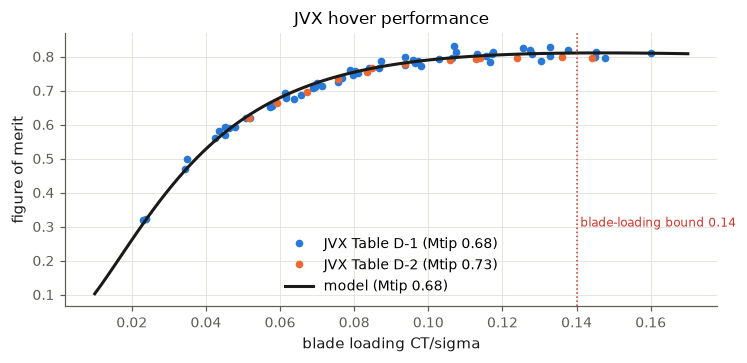

In [4]:
from examples import jvx_rotor_calibration as jvx
hover_data = jvx.load_hover()
rotor_jvx = jvx.jvx_rotor()
loads = onp.linspace(0.01, 0.17, 100)
fm_model = [jvx.predict(rotor_jvx, x, 0.0, 0.68)[1] for x in loads]
fig, ax = plt.subplots(figsize=(7, 3.4))
for table, color in (("D-1", blue), ("D-2", orange)):
    mask = onp.array([t == table for t in hover_data.table])
    ax.plot(hover_data.blade_loading[mask], hover_data.figure_of_merit[mask], "o", ms=4, color=color,
            label=f"JVX Table {table} (Mtip {'0.68' if table == 'D-1' else '0.73'})")
ax.plot(loads, fm_model, color=ink, lw=2, label="model (Mtip 0.68)")
ax.axvline(0.14, color=red, ls=":", lw=1); ax.annotate("blade-loading bound 0.14", (0.141, 0.3), fontsize=8, color=red)
ax.set(xlabel="blade loading CT/sigma", ylabel="figure of merit", title="JVX hover performance")
ax.legend(); plt.tight_layout(); plt.show()

Hover power on a Halo-like rotor at fixed thrust, against rotor speed: a slower rotor has less profile power but higher blade
loading. The minimum-power tip speed lies beyond the blade-loading limit (shaded), so the limit stops the rotor slowing further. This is why `blade_loading <= 0.14` is often active in the Halo's hover:

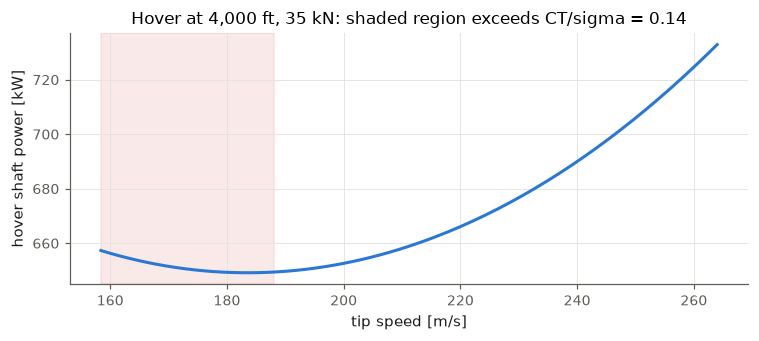

In [5]:
rotor = MomentumProfileRotor(area_disk_m2=onp.pi * 4.8**2, solidity=0.09)
thrust_N = 35000.0
speeds = onp.linspace(33, 55, 200)
results = [rotor.evaluate(0.0, asb.Atmosphere(1219.0), thrust_N=thrust_N, speed_rad_s=w) for w in speeds]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(speeds * 4.8, [r.shaft_power_W / 1e3 for r in results], color=blue, lw=2)
loading = onp.array([r.blade_loading for r in results])
ax.axvspan(speeds[0] * 4.8, speeds[onp.argmin(onp.abs(loading - 0.14))] * 4.8, color=red, alpha=0.1)
ax.set(xlabel="tip speed [m/s]", ylabel="hover shaft power [kW]",
       title="Hover at 4,000 ft, 35 kN: shaded region exceeds CT/sigma = 0.14")
plt.tight_layout(); plt.show()

## 4. Airplane mode

Each blade section sees $\sqrt{(\Omega r)^2 + V^2}$, so profile power integrates
$I(\lambda) = \int_0^1 x^2\sqrt{x^2 + \lambda^2}\,dx$ (closed form in `profile_integral`; $I(0) = 1/4$), and

$$C_P = C_T\lambda + \kappa C_T\lambda_i + \frac{\sigma}{2}\,c_d\, I(\lambda),\qquad \lambda_i = -\frac{\lambda}{2} + \sqrt{\frac{\lambda^2}{4} + \frac{C_T}{2}},$$

$$c_d = d_0 + d_1 x + d_2 x^2 + a + b\lambda^2,\qquad x = \frac{C_T/\sigma}{1 + 3\lambda^2}.$$

Referring the loading to the mean section dynamic pressure, the factor $(1 + 3\lambda^2)$, lets one polar serve both modes. The
increment $a + b\lambda^2$ carries twist off-design and hub/spinner drag in cruise. Check the closed-form integral by quadrature:

In [6]:
from scipy.integrate import quad
for lam in (0.1, 0.4, 0.8):
    numeric = quad(lambda x: x**2 * onp.sqrt(x**2 + lam**2), 0, 1)[0]
    print(f"lambda {lam}: closed form {profile_integral(lam):.10f}, quadrature {numeric:.10f}")
check("profile_integral matches quadrature", all(abs(profile_integral(l) - quad(lambda x: x**2 * onp.sqrt(x**2 + l**2), 0, 1)[0]) < 1e-10
                                                 for l in (0.1, 0.4, 0.8)))
check("profile_integral tends to 1/4 at zero advance ratio", abs(profile_integral(1e-6) - 0.25) < 1e-6)

lambda 0.1: closed form 0.2524656472, quadrature 0.2524656472
lambda 0.4: closed form 0.2855277599, quadrature 0.2855277599
lambda 0.8: closed form 0.3689694374, quadrature 0.3689694374
PASS  profile_integral matches quadrature
PASS  profile_integral tends to 1/4 at zero advance ratio


Propulsive efficiency against the JVX airplane-mode data (Phase II, $\lambda$ 0.26-0.56):

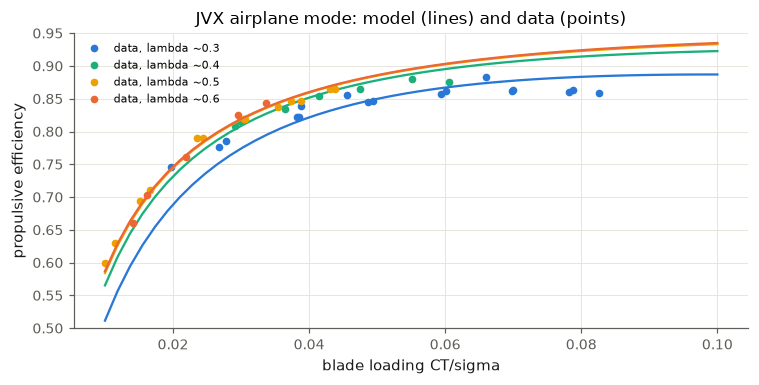

In [7]:
airplane_data = jvx.load_airplane()
fig, ax = plt.subplots(figsize=(7, 3.6))
groups = sorted(set(onp.round(airplane_data.advance_ratio, 1)))
colors = [blue, aqua, yellow, orange, red]
for group, color in zip(groups, colors):
    mask = onp.round(airplane_data.advance_ratio, 1) == group
    ax.plot(airplane_data.blade_loading[mask], airplane_data.efficiency[mask], "o", ms=4, color=color, label=f"data, lambda ~{group}")
    lam = float(onp.mean(airplane_data.advance_ratio[mask]))
    x = onp.linspace(0.01, 0.1, 50)
    ax.plot(x, [jvx.predict(rotor_jvx, xi, lam, 0.58)[1] for xi in x], color=color, lw=1.5)
ax.set(xlabel="blade loading CT/sigma", ylabel="propulsive efficiency", ylim=(0.5, 0.95),
       title="JVX airplane mode: model (lines) and data (points)")
ax.legend(fontsize=7); plt.tight_layout(); plt.show()

## 5. Reproducing the calibration

The model is **linear in its drag constants**, so both fits are ordinary least squares (`examples/jvx_rotor_calibration.py`):
the hover polar $d_0, d_1, d_2$ on Table D-1 with $\kappa$ fixed at 1.15 (not identifiable separately from the loading terms over this
range), then the airplane-mode increment $a, b$ on the Phase II data. The results are the class defaults:

In [8]:
report = jvx.calibration_report()
print(f"hover polar d0, d1, d2   = {onp.round(report.polar, 6)}   (class default {onp.round(MomentumProfileRotor().drag_polar, 6)})")
print(f"airplane increment a, b  = {onp.round(report.increment, 6)}   (class default {onp.round(MomentumProfileRotor().drag_increment_airplane, 6)})")
print(f"hover FM RMS error {report.hover_fm_rms:.4f}; Mtip 0.73 power error max {report.hover_d2_power_error_max:.3f} (not fitted)")
print(f"airplane efficiency RMS error {report.airplane_eta_rms:.4f}, max {report.airplane_eta_max:.4f}")
check("the calibration reproduces the defaults in rotor.py",
      onp.allclose(report.polar, MomentumProfileRotor().drag_polar) and onp.allclose(report.increment, MomentumProfileRotor().drag_increment_airplane))

hover polar d0, d1, d2   = [ 0.018498 -0.221639  1.066255]   (class default [ 0.018498 -0.221639  1.066255])
airplane increment a, b  = [0.001687 0.01876 ]   (class default [0.001687 0.01876 ])
hover FM RMS error 0.0123; Mtip 0.73 power error max 0.022 (not fitted)
airplane efficiency RMS error 0.0128, max 0.0363
PASS  the calibration reproduces the defaults in rotor.py


## 6. Limits, and the cruise pathology

The rotor returns limits for the caller to enforce (`get_limits()`), and `build_flight_point` adds them as constraints at every
point:

| Limit | Default | Why |
|---|---|---|
| `blade_loading_max` | 0.14 | stall margin; the upper end of the calibration data (0.16) |
| `mach_tip_helical_max` | 0.80 | compressibility; the data span tip Mach 0.58-0.73 |
| `advance_ratio_max` | 0.60 | validity: the airplane data reach 0.56 |
| `speed_tip_max_m_s` | design tip speed | the rotor is designed for its hover tip speed |
| `max_shaft_power_W` | gearbox output rating | drive-system rating |

The model has no blade stall. At high $\lambda$ the $(1 + 3\lambda^2)$ reference makes heavily loaded blades look lightly loaded,
so **cruise power keeps falling as the rotor slows**, and an unconstrained optimizer drives $\lambda$ to 0.8 and beyond, far outside
the data (plan 016). The `advance_ratio <= 0.60` bound, not physics, sets the cruise rotor speed. Blade-element theory with stall is
the deferred remedy. See it:

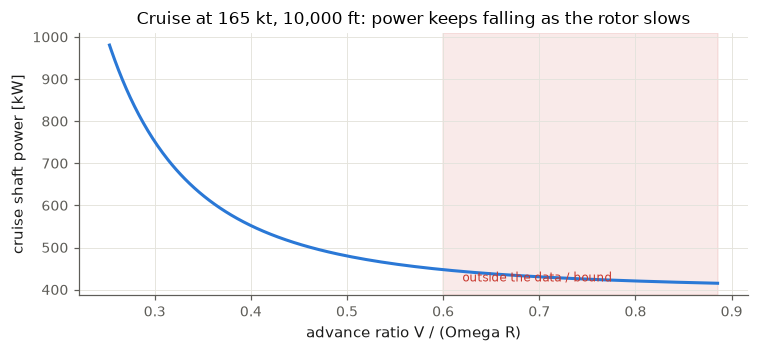

PASS  cruise power decreases monotonically with advance ratio over this range (the pathology)


In [9]:
cruise_rotor = MomentumProfileRotor(area_disk_m2=onp.pi * 4.8**2, solidity=0.09).in_airplane_mode()
velocity_m_s, thrust_cruise_N = 85.0, 4500.0
speeds = onp.linspace(20, 70, 200)
cruise = [cruise_rotor.evaluate(velocity_m_s, asb.Atmosphere(3048.0), thrust_N=thrust_cruise_N, speed_rad_s=w) for w in speeds]
lam = onp.array([c.advance_ratio for c in cruise])
fig, ax = plt.subplots(figsize=(7, 3.3))
ax.plot(lam, [c.shaft_power_W / 1e3 for c in cruise], color=blue, lw=2)
ax.axvspan(0.6, lam.max(), color=red, alpha=0.1)
ax.annotate("outside the data / bound", (0.62, ax.get_ylim()[0] if False else min(c.shaft_power_W for c in cruise) / 1e3 * 1.01), fontsize=8, color=red)
ax.set(xlabel="advance ratio V / (Omega R)", ylabel="cruise shaft power [kW]",
       title="Cruise at 165 kt, 10,000 ft: power keeps falling as the rotor slows")
plt.tight_layout(); plt.show()
power_kW = onp.array([c.shaft_power_W for c in cruise]) / 1e3
check("cruise power decreases monotonically with advance ratio over this range (the pathology)",
      onp.all(onp.diff(power_kW[onp.argsort(lam)]) < 0))

## 7. How the Halo builds its rotor

In `build_halo_aircraft`: disk area, solidity and design tip speed are design variables; rotor mass comes from the AFDD rotor-group
equations (blades + hub) with an XV-15 calibration factor; the shaft-power limit is the gearbox output rating; the tip-speed limit is
the design tip speed. `rotor_speed_physics=False` restores the actuator disk (rule 10).

In [10]:
import examples.halo_sizing as hs
source = inspect.getsource(hs.build_halo_aircraft)
start = source.find("    if a.rotor_speed_physics:")
print(source[start:start + 820])
start = source.find("    mass_rotors_kg = ")
print(source[start:start + 260])

    if a.rotor_speed_physics:
        rotor = MomentumProfileRotor(area_disk_m2=d.area_disk_m2, solidity=solidity, mass_kg=mass_rotors_kg / a.count_rotors,
                                     max_shaft_power_W=gearbox.power_rated_W * gearbox.efficiency,
                                     speed_tip_max_m_s=speed_tip_m_s)
    else:
        rotor = ActuatorDiskPropulsor(area_disk_m2=d.area_disk_m2, mass_kg=mass_rotors_kg / a.count_rotors,
                                      coefficient_of_performance=a.figure_of_merit,
                                      coefficient_of_performance_airplane=a.coefficient_airplane,
                                      max_shaft_power_W=gearbox.power_rated_W * gearbox.efficiency,
                                      speed_tip_max_m_s=speed_tip_m_s)
    battery = build_halo
    mass_rotors_kg = factors.rotor * afdd.mass_rotor_group_afdd82_kg(a.count_rotors, a.count_blades, radius_m, chord_m,
                                                           

## Summary

- The actuator disk has a closed form for given thrust; for given power the caller supplies the induced velocity as a variable and
  drives the returned residual to zero.
- `MomentumProfileRotor`: momentum induced power plus profile power from one loading-referred drag polar, hover and airplane mode,
  calibrated by linear least squares on JVX data (FM RMS 0.012, efficiency RMS 0.013).
- It returns blade loading, tip Mach and advance ratio for the caller to bound; without stall physics the advance-ratio bound sets
  cruise rotor speed.

## Check yourself

<details><summary>1. Why can't the Halo's rotor tip speed be a design variable with the actuator disk model?</summary>

Actuator-disk power does not depend on rotor speed (`speed_rad_s` is accepted and ignored), so the optimizer would get no information about it; only the tip-speed bound and the rotor weight equation would see it. The momentum + profile model makes power depend on tip speed and solidity.
</details>

<details><summary>2. In the Halo results the cruise advance ratio sits at 0.60. Is that an optimum of the physics?</summary>

No, it is a validity bound (section 6). Read it as "this model cannot say how slow the rotor should turn in cruise"; a BEM rotor map with stall would.
</details>

<details><summary>3. Why fix kappa at 1.15 rather than fit it?</summary>

Over the data range the induced term ($\kappa C_T^{3/2}$) and the loading-dependent profile terms are nearly collinear, so a free fit trades them against each other and returns an unphysical kappa below 1 (the calibration module's docstring).
</details>

In [11]:
check_summary()

6 of 6 checks passed
